# Changes and removals

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WebIterate-Dev/extension-tracker-notebooks/blob/main/03-changes-and-removals.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/WebIterate-Dev/extension-tracker-notebooks/blob/main/03-changes-and-removals.ipynb)

Every set of [Extension Tracker](https://extensiontracker.com)'s data has a change log: one row for
each field that changed, dated the day it was noticed. This notebook counts the changes, follows
removals and new extensions, and finds extensions that asked for more access.

The [getting started](01-getting-started.ipynb) notebook explains the files.

## Setup

Colab and Kaggle already have pandas, pyarrow and matplotlib, so there's nothing to install. On
Kaggle, the notebook needs internet access to read the files: if a cell can't connect, turn on
Internet in the notebook's settings, which Kaggle allows once your account has a verified phone
number.

In [1]:
import json
import urllib.request
from datetime import date

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator


# The set of files to read. Sets come out every Sunday and never change, so a
# notebook that reads one dated set gives the same results every time.
# https://data.extensiontracker.com/index.json lists every set.
SET = "2026-09-29"
BASE = f"https://data.extensiontracker.com/{SET}/"


def read(name, **options):
    """Read one of the set's Parquet files, such as "extensions"."""
    return pd.read_parquet(f"{BASE}{name}-{SET}.parquet", dtype_backend="numpy_nullable", **options)


DATA = "#0b6f85"  # the color of Extension Tracker's charts
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_colwidth = 60

In [2]:
extensions = read(
    "extensions",
    columns=["id", "name", "status", "category", "users", "first_seen", "removed_on"],
)
changes = read("changes")
print(f"{len(changes):,} changes, from {changes['date'].min()} to {changes['date'].max()}")
changes.head()

14,735 changes, from 2026-09-27 to 2026-09-29


,id,date,field,old_value,new_value
0,aakhcgcbiehjpkmhngjjommcdhnobpho,2026-09-27,pkg_version,"""0.3.70""","""0.3.71"""
1,aaoogilmfmepcikcbpdphkljlndmajbh,2026-09-27,pkg_version,"""4.1.65""","""4.1.67"""
2,abbodjcdomkmdapmllfballhkebccbbf,2026-09-27,pkg_version,"""0.35.0""","""0.36.0"""
3,acfjihfmahkhoahbdhifnjilcdfiffpe,2026-09-27,pkg_version,"""0.24.0""","""0.64.18"""
4,afbgikioommabcnmgfhmoedgamcfggoi,2026-09-27,pkg_version,"""2.0.1""","""2.2.0"""


The change log also has `status` rows for themes, apps and other items. Joining it with the
extensions file keeps the extensions. `old_value` and `new_value` are JSON, so we decode them.

`version` is the version the store listing shows, and `pkg_version` the one Google's update service
offers, so a new version usually appears in both.

In [3]:
def decode(value):
    return json.loads(value) if isinstance(value, str) and value else None


changes = changes[changes["id"].isin(extensions["id"])].copy()
changes["old"] = changes["old_value"].map(decode)
changes["new"] = changes["new_value"].map(decode)
changes["field"].value_counts().to_frame("changes")

,changes
field,
version,4284
pkg_version,4265
size,3447
summary,576
permissions,487
host_permissions,393
content_script_matches,312
name,288
languages,129


Changes to a few fields, by day:

In [4]:
fields = ["version", "name", "permissions", "host_permissions", "status", "esb_allowlist"]
by_day = changes.pivot_table(index="date", columns="field", values="id", aggfunc="count", fill_value=0)
by_day.reindex(columns=fields, fill_value=0)

field,version,name,permissions,host_permissions,status,esb_allowlist
date,,,,,,
2026-09-27,46,4,4,1,0,0
2026-09-28,1435,103,169,131,7,1
2026-09-29,2803,181,314,261,7,0


## Removals

An extension counts as removed once it has been missing from the store's lists on three daily checks
in a row and the store no longer offers it. The store doesn't say why an extension was removed.

4 extensions removed since tracking began on 26 September 2026


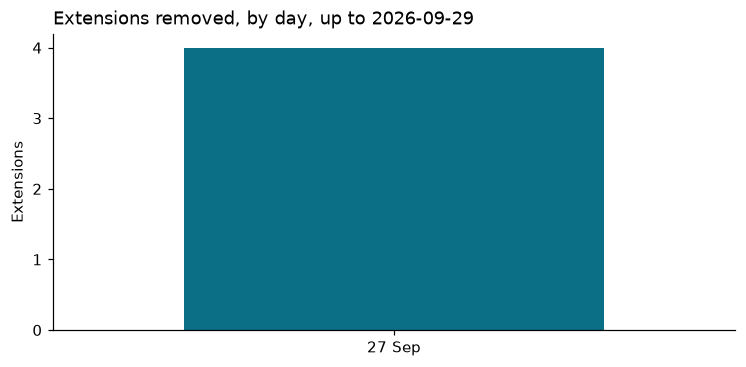

In [5]:
removed = extensions[extensions["status"] == "removed"]
print(f"{len(removed):,} extensions removed since tracking began on 26 September 2026")

per_day = removed["removed_on"].value_counts().sort_index()
per_day = per_day.reindex(pd.date_range(per_day.index.min(), per_day.index.max()).date, fill_value=0)
ax = per_day.plot.bar(figsize=(8, 3.5), color=DATA, width=0.8)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title(f"Extensions removed, by day, up to {SET}", loc="left")
ax.set_xticklabels([day.strftime("%d %b") for day in per_day.index], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("Extensions")
plt.show()

The removed extensions that had the most users at their last check:

In [6]:
removed.sort_values("users", ascending=False).head(10)[["name", "users", "category", "removed_on"]]

,name,users,category,removed_on
74301,Twitch.tv True Quality,48,lifestyle/entertainment,2026-09-27
2761,AutoRoom,7,productivity/tools,2026-09-27
13591,b9b,5,lifestyle/games,2026-09-27
215043,Miles — Lead Concierge Assistant,5,productivity/workflow,2026-09-27


An extension the store's lists have left out, but that the store still offers for Chrome to install,
is unlisted rather than removed: anyone with a direct link can still get it.

In [7]:
unlisted = extensions[extensions["status"] == "unlisted"]
print(f"{len(unlisted):,} extensions are unlisted")

0 extensions are unlisted


## New extensions

`first_seen` is the first day the store's list of items included an extension. Tracking began on
26 September 2026, so everything listed then has that date.

In [8]:
new_extensions = extensions[extensions["first_seen"] > date(2026, 9, 26)]
new_extensions["first_seen"].value_counts().sort_index().to_frame("new extensions")

,new extensions
first_seen,
2026-09-27,476
2026-09-28,451
2026-09-29,773


## Asking for more access

A `permissions` or `host_permissions` row holds the whole list before and after the change, so the
difference shows what was added.

In [9]:
access = changes[changes["field"].isin(["permissions", "host_permissions"])].copy()
access["added"] = [sorted(set(new or []) - set(old or [])) for old, new in zip(access["old"], access["new"])]

added = access.explode("added").dropna(subset=["added"])
added["added"].value_counts().head(15).to_frame("times added")

,times added
added,
alarms,75
scripting,69
offscreen,38
sidePanel,36
contextMenus,33
activeTab,30
unlimitedStorage,29
identity,27
storage,25


Extensions that added a pattern for every website, such as `<all_urls>` or `*://*/*`, to their
permissions or host permissions:

In [10]:
FIELDS = ["permissions", "host_permissions", "content_script_matches"]


def every_website(pattern):
    """<all_urls>, or a site pattern whose host is "*", such as *://*/*."""
    if pattern == "<all_urls>":
        return True
    scheme, separator, rest = pattern.partition("://")
    return bool(separator) and rest.split("/", 1)[0] == "*"


wider = access[[any(every_website(pattern) for pattern in patterns) for patterns in access["added"]]]
wider = wider.merge(extensions[["id", "name", "users"]], on="id")
wider.sort_values("users", ascending=False)[["date", "name", "users", "field", "added"]].head(15)

,date,name,users,field,added
13,2026-09-29,Gmail App - Mail Application for Gmail™,100000,host_permissions,[<all_urls>]
20,2026-09-29,Mouse Coordinates,3000,host_permissions,[<all_urls>]
9,2026-09-29,Full Stack Assistant,409,host_permissions,"[<all_urls>, https://cloudflare-dns.com/*, https://dns.g..."
2,2026-09-28,摸鱼盯盘 - A股实时行情提醒助手,210,host_permissions,"[<all_urls>, https://33.push2his.eastmoney.com/*, https:..."
15,2026-09-29,AudioDich - Realtime Subtitle & Translation,181,host_permissions,[<all_urls>]
4,2026-09-28,Mstock Image Generator,160,host_permissions,"[http://*/*, http://127.0.0.1:*/*, http://localhost:*/*]"
6,2026-09-29,DaPartyraiser AutoDarts Add-on,90,host_permissions,"[http://*/*, https://sync.triple-twenties.de/*]"
21,2026-09-29,!Native: Learn languages while using Chrome,85,host_permissions,[http://*/*]
17,2026-09-29,HermesAI,77,host_permissions,[<all_urls>]
3,2026-09-28,引力智擎,73,host_permissions,"[*://*.iesdouyin.com/*, <all_urls>]"


## Enhanced Safe Browsing

Chrome's Enhanced Safe Browsing trusts some extensions and warns before installing the others.
Google's update service says which, and the status changes in batches.
[Extension Tracker explains the status](https://extensiontracker.com/enhanced-safe-browsing).

In [11]:
esb = changes[changes["field"] == "esb_allowlist"]
esb.groupby(["date", "new"]).size().unstack(fill_value=0).rename(
    columns={True: "now trusted", False: "no longer trusted"}
)

new,no longer trusted
date,
2026-09-28,1


## Credit

The data is under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/): if you use it, credit
Extension Tracker and link to https://extensiontracker.com. Names, summaries and other text written
by developers belong to them. The data is collected automatically, so check an important fact against
the extension's store listing before relying on it.